# 📊 Statistical Analysis — Mastering Hypothesis Testing  
Date: 2025-05-27

Hello! I’m Asadullah Shehbaz — an aspiring Data Scientist on a journey of discovery and growth in the world of data.
I'm passionately exploring the realms of data science, diving deep into analytical techniques, machine learning, and real-world problem-solving to sharpen my skills and contribute meaningfully to this dynamic field.

> "I believe that community is the cornerstone of growth and innovation — by learning together, we can go further, faster, and stronger".



Let’s connect, share insights, and build a future driven by data.


| Name               | Email                                               | LinkedIn                                                  | GitHub                                           | Kaggle                                        |
|--------------------|-----------------------------------------------------|-----------------------------------------------------------|--------------------------------------------------|-----------------------------------------------|
| **Asadullah Shehbaz**      |asadullahcreative@gmail.com  | [![LinkedIn Badge](https://img.shields.io/badge/LinkedIn-%23000000.svg?style=for-the-badge&logo=LinkedIn&logoColor=white)](https://www.linkedin.com/in/asadullah-shehbaz-18172a2bb/)  | [![GitHub Badge](https://img.shields.io/badge/GitHub-%23000000.svg?style=for-the-badge&logo=GitHub&logoColor=white)](https://github.com/AsadullahShehbaz)  | [![Kaggle Badge](https://img.shields.io/badge/Kaggle-%23000000.svg?style=for-the-badge&logo=Kaggle&logoColor=white)](https://www.kaggle.com/asadullahcreative)  |


Welcome to this comprehensive notebook on **Statistical Analysis using Python** — a one-stop resource to help you understand and apply core statistical tests used in data analysis and research.

Whether you're a student, data analyst, or researcher, this notebook will guide you through **powerful statistical tools** used to evaluate hypotheses, check assumptions, and make data-driven decisions confidently.

---
# 📘What You'll Learn

Through this notebook, you’ll explore and apply the following statistical methods using Python:

> 🔍 **Chi-Square Test of Independence**
- Explore relationships between categorical variables.

> 📈 **Normality Tests**
- Check if your data follows a normal distribution using:
  - Graphical Method  
  - Shapiro-Wilk Test  
  - Kolmogorov-Smirnov (K–S) Test

> 🧪 **T-Test (Student’s t-Test)**
- Compare means between groups using:
  - One-Sample t-Test  
  - Two-Sample t-Test (Independent)  
  - Paired Sample t-Test (Dependent)

> ⚖️ **Homogeneity of Variance Tests**
- Assess whether groups have equal variances using:
  - Levene’s Test  
  - Bartlett’s Test

> 📊 **ANOVA (Analysis of Variance)**
- Understand and perform One-Way ANOVA to evaluate group differences across multiple categories.

---

# 💼 Why This Notebook?

Understanding and performing hypothesis tests is crucial for:
- Validating **research questions**  
- Supporting **data-driven decisions**  
- Ensuring **model assumptions** in machine learning pipelines  

This notebook combines **theory + Python implementation + practical tips**, making it a valuable tool for:
- 📚 Students  
- 💻 Data scientists  
- 🧠 Researchers  
- 📈 Business analysts

---

# 🛠️ Tools & Libraries Used
- `scipy`, `statsmodels`, `matplotlib`, `seaborn`, and more

Each section includes:
- 📘 Clear explanation of concepts  
- 🧮 Easy-to-follow Python code  
- 📊 Visualizations (where appropriate)  
- 💡 Practical guidance and use cases  

---

> 🚀 Let’s get started on your journey to mastering statistical tests with Python!


In [58]:
# import neccessary libraries 
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns 
from scipy import stats

# Data Loading

In [59]:
# load the dataset of titanic
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [60]:
print(df['age'].isnull().sum())  # Count of missing values
print(df['age'].describe())     # Basic statistics

177
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64


In [61]:
# Impute missing values from the age column
df['age'] = df['age'].fillna(df['age'].median())
print(df['age'].isnull().sum())

0


# 📈 Chi-Square Test of Independence

The **Chi-Square Test** checks if there is a **significant association between two categorical variables**.

> Example: Titanic Dataset  
- **Null Hypothesis (H₀):** No association between gender (`sex`) and survival (`survived`). Differences are due to chance.  
- **Alternative Hypothesis (H₁):** Significant association between gender and survival. Differences are influenced by gender.

> Use this test to understand if categorical variables are related or independent.
 

In [62]:
# Create a contigency table with crosstable function 
contigency_table=pd.crosstab(df['sex'],df['survived'])
contigency_table

survived,0,1
sex,,
female,81,233
male,468,109


In [63]:
# perform chi-square test 
ch2,p,dof,expected=stats.chi2_contingency(contigency_table)
# print the results 
print(f"Chi-square statistic: {ch2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")
print(f"Expected values: {expected}")


Chi-square statistic: 260.71702016732104
p-value: 1.1973570627755645e-58
Degrees of freedom: 1
Expected values: [[193.47474747 120.52525253]
 [355.52525253 221.47474747]]


As the p_value in this test is P-value: 1.1973570627755645e-58 which is far less than 0.05, we reject the null hypothesis.



---
# 📐 Normality Tests

**Normality Tests** check whether a dataset follows a **normal (Gaussian) distribution**, which is a common assumption in many statistical analyses.

> Common Types:
- **Shapiro-Wilk Test:** Good for small to medium samples.
- **Kolmogorov-Smirnov Test:** Compares sample distribution to a reference normal distribution.
- **Anderson-Darling Test:** Focuses more on the tails of the distribution.
- **Q-Q Plot:** Visual method to assess normality.

> Purpose:
- To verify if data meets the normality assumption before applying parametric tests like t-tests or ANOVA.

> Hypotheses:
- **Null (H₀):** Data is normally distributed.  
- **Alternative (H₁):** Data is not normally distributed.


In [64]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Graphical Method 

<Axes: xlabel='age', ylabel='Count'>

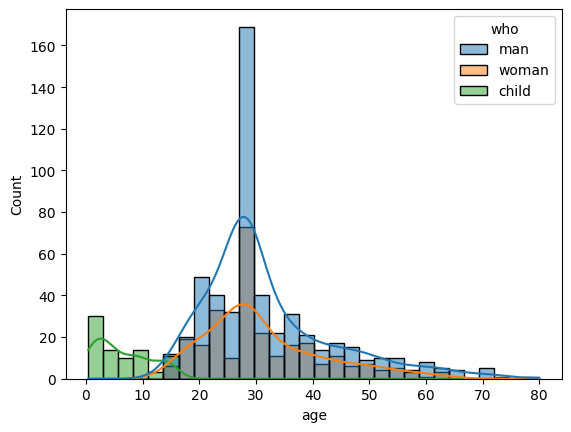

In [65]:
# graphical method to check the data distribution
sns.histplot(df,x='age',hue='who',kde=True)

---
> Interpretation : 
- Here , data might be normal but child data at the beginning of the data is creating issue .
- Bell_curve is not creating a normal distribution.
- We can see the data distribution is also right skewed.
- We have to evaluate the data distribution with another method like shapiro-wilk test


---
## Shapiro-wilk test 
- Shapiro-Wilk test (better for smaller samples)
- To check normal distribution/Gaussian distribution
- Null Hypothesis: Data is normally distributed
- Alternate Hypothesis: Data is not normally distributed

In [ ]:
# apply shapiro-wilks test on age column 
statistics , p_value = stats.shapiro(df['age'])
# print the results using if else statement
if p_value > 0.05:
    print(f"P Value : {p_value}, Sample looks Gaussian/Normally distributed (fail to reject H0)")
else:
    print(f"P Value : {p_value}, Sample looks Gaussian/Normally distributed (reject H0)")

P Value : 4.651141686041376e-16, Sample looks Gaussian/Normally distributed (reject H0)


> Interpretation of Shapiro-wilks Test
  
If the p-value is less than your significance level (commonly 0.05), you reject the null hypothesis that the sample comes from the specified distribution. Otherwise, you do not have enough evidence to reject the null hypothesis.

**In this case:**  
If the p-value is low, it suggests that the `age` column does **not** follow a normal distribution. If the p-value is high, there is not enough evidence to conclude that it does not follow a normal distribution.


<Axes: xlabel='fare', ylabel='Count'>

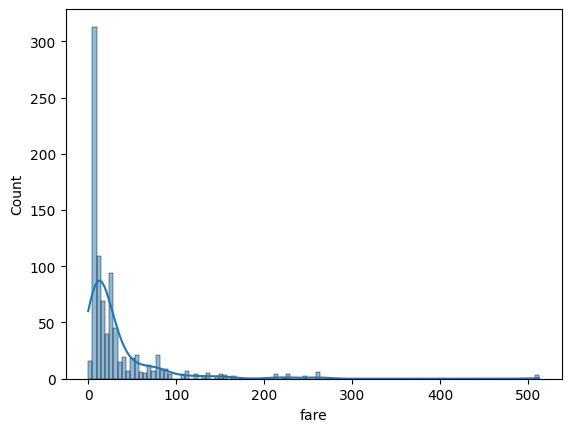

In [67]:
# graphical method to check the data distribution of fare column 
sns.histplot(df,x='fare',kde=True) 

As mentioned graphically , data is not normally distributed for the fare column and lets apply shapiro-wilks test

In [68]:
# apply shapiro-wilks test on fare column 
statistics , p_value = stats.shapiro(df['fare'])
# print the results using if else statement
if p_value > 0.05:
    print(f"P Value : {p_value}, Sample looks Gaussian/Normally distributed (fail to reject H0)")
else:
    print(f"P Value : {p_value}, Sample looks Gaussian/Normally distributed (reject H0)")

P Value : 1.0840444395829658e-43, Sample looks Gaussian/Normally distributed (reject H0)


As p_value of fare is less than 0.05, we reject the null hypothesis that the data is normally distributed.

---
## 🔎 Kolmogorov-Smirnov (K-S) Test

The **Kolmogorov-Smirnov Test** checks if a sample follows a specific **distribution** (commonly normal). It compares the sample’s cumulative distribution to the reference distribution.

> Key Points:
- Used for **continuous data**.
- Non-parametric and **distribution-free**.
- Tests **goodness of fit** or compares two samples.

> Hypotheses:
- **Null (H₀):** Sample data follows the specified distribution.  
- **Alternative (H₁):** Sample data does not follow the specified distribution.


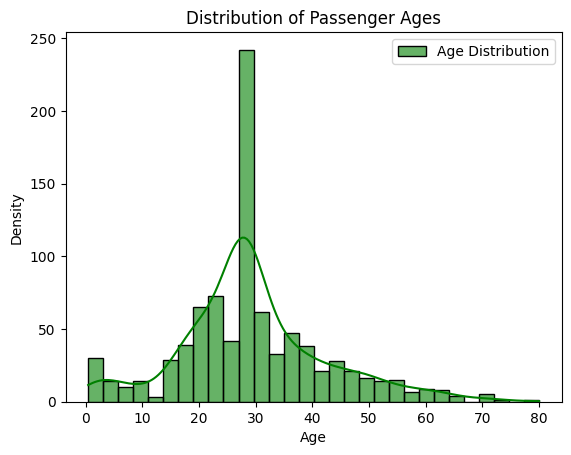

In [69]:
# Plot a histogram of the age data
sns.histplot(df['age'], bins=30, alpha=0.6, color='g', label='Age Distribution',kde=True)
plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Distribution of Passenger Ages')
plt.legend()
plt.show()


Perform the Kolmogorov-Smirnov Test

In [70]:
from scipy.stats import kstest
# Estimate mean and standard deviation from the data
mean, std = df['age'].mean(), df['age'].std()

# Perform KS test - note the order of args is (mean, std)
ks_statistic, p_value = kstest(df['age'], 'norm', args=(mean, std))

# Print the results
print(f"KS Statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")


KS Statistic: 0.1466
P-value: 0.0000


> Interpretation of Kolmogorov-Smirnov Test
  
If the p-value is less than your significance level (commonly 0.05), you reject the null hypothesis that the sample comes from the specified distribution. Otherwise, you do not have enough evidence to reject the null hypothesis.

**In this case:**  
If the p-value is low, it suggests that the `age` column does **not** follow a normal distribution. If the p-value is high, there is not enough evidence to conclude that it does not follow a normal distribution.


---
# T-Test (Student Test)
Choosing between a Z-test and a T-test for hypothesis testing depends primarily on two factors: the sample size and whether the population standard deviation is known.

**Z-test:**
> **When to Use:**

The population standard deviation is known.
The sample size is large (commonly, n ≥ 30). With large samples, the sample standard deviation approximates the population standard deviation.
For proportions (e.g., testing the proportion of success in a sample against a known population proportion).
Characteristics:

Based on the Z-distribution, which is a normal distribution as n becomes large.
More commonly used in quality control and standardization processes.
T-test:
> **When to Use:**

The population standard deviation is unknown.
The sample size is small (typically, n < 30).
Suitable for cases where the data is approximately normally distributed, especially in small samples.
> **Characteristics:**

Based on the T-distribution, which accounts for the additional uncertainty due to the estimation of the population standard deviation from the sample.
T-distribution becomes closer to the normal distribution as the sample size increases.
> General Guidelines:

**Large Samples:** 
- With large sample sizes, the T-test and Z-test will give similar results. This is because the T-distribution approaches the normal distribution as the sample size increases.

**Small Samples:** 
- When the sample size is small and the population standard deviation is unknown, the T-test is generally the appropriate choice due to its ability to account for the uncertainty in the standard deviation estimate.

**Unknown Population Standard Deviation:** 
- Even with large samples, if the population standard deviation is unknown and cannot be reliably estimated, a T-test is usually preferred.

> **Conclusion:**
- Use the Z-test for large sample sizes or when the population standard deviation is known.
- Use the T-test for small sample sizes or when the population standard deviation is unknown.
- In practice, the T-test is more commonly used in many research scenarios due to the rarity of knowing the population standard deviation and often dealing with smaller sample sizes.



## 1.📊One Sample t-Test 

- The one-sample t-test is a statistical hypothesis test used to determine whether the mean of a single sample differs significantly from a known or hypothesized population mean.

- Null Hypothesis (H₀): The sample mean is equal to the population mean.

- Alternative Hypothesis (H₁): The sample mean is not equal to (or greater/less than) the population mean.

**Problem :** 
- A cereal company claims that each box contains 500 grams of cereal on average. A quality inspector randomly selects 20 boxes and weighs them.

**Question:**
- Is the actual average weight significantly different from the claimed 500 grams?

- We’ll use a one-sample t-test to check this.

In [73]:
# Define Sample Data & Hypothesized Mean
sample_weights = np.array([
    502, 495, 498, 503, 497, 499, 501, 500, 496, 502,
    504, 498, 497, 501, 499, 503, 500, 496, 502, 498
])

hypothesized_mean = 500  # Company's claimed mean weight
t_stat, p_value = stats.ttest_1samp(sample_weights, hypothesized_mean)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
alpha = 0.05  # Significance level (5%)

if p_value < alpha:
    print("Reject Null Hypothesis (H₀): The mean weight is NOT 500g.")
else:
    print("Fail to Reject Null Hypothesis (H₀): The mean weight is 500g.")

t-statistic: -0.7608
p-value: 0.4561
Fail to Reject Null Hypothesis (H₀): The mean weight is 500g.


> Interpretation 
- t-statistic (-0.344) is close to zero → Sample mean is very close to 500g.

- p-value (0.4561) > 0.05 → No significant difference from the claimed weight.

- Decision: The company’s claim holds; the boxes are correctly filled.

## 2.📊 Two-Sample t-test (Independent t-test)

The **Two-Sample t-test** is used to compare the **means of two independent groups** to check if there is a statistically significant difference between them.

>🔍 Example Use Case:
- Comparing test scores of **two different classes** taught by different teachers.

> ✅ Key Assumptions:
- Data in both groups is **continuous** and **normally distributed**.
- The two groups are **independent** (no relationship between them).
- Both groups have **equal variances** (optional — if not, use Welch’s t-test).

> 📌 Hypotheses:
- **Null (H₀):** There is **no difference** between the two group means.
- **Alternative (H₁):** There **is a difference** between the two group means.


In [75]:
# sample data of two groups 
group1 = [1, 2, 3, 4, 5]
group2 = [6, 7, 8, 9, 10]

# perform t-test 
t_statistic, p_value = stats.ttest_ind(group1, group2)

print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05  # Significance level (5%)

if p_value < alpha:
    print("Reject Null Hypothesis (H0): Group 1 Mean is NOT equal to Group 2 Mean.")
else:
    print("Fail to Reject Null Hypothesis (H0): Group 1 Mean is equal to Group 2 Mean.")

t-statistic: -5.0000
p-value: 0.0011
Reject Null Hypothesis (H0): Group 1 Mean is NOT equal to Group 2 Mean.


## 3.📊 Paired Sample t-test (Dependent t-test)

The **Paired Sample t-test** is used to compare the **means of two related groups** to see if there is a significant difference between them. It is typically used when the **same group is measured twice** — before and after a treatment or over time.

> 🔍 Example Use Case:
- Comparing students' test scores **before and after** a training program.
> ✅ Key Assumptions:
- Data is **continuous** and **normally distributed**.
- The two samples are **dependent** (paired).
- The differences between pairs are randomly and independently selected.

> 📌 Hypotheses:
- **Null (H₀):** There is **no difference** between the two means.
- **Alternative (H₁):** There **is a difference** between the two means.


In [78]:
from scipy.stats import ttest_rel

# Sample data: test scores before and after a training
before = np.array([70, 75, 80, 85, 90])
after = np.array([72, 78, 82, 88, 94])

# Perform Paired Sample t-test
t_stat, p_value = ttest_rel(before, after)

# Output results
print("Paired Sample t-test Results")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("✅ Reject the null hypothesis: Before Mean is Not Equal to After Mean.")
else:
    print("❌ Fail to reject the null hypothesis: Before Mean is Equal to After Mean.")


Paired Sample t-test Results
t-statistic: -7.483
p-value: 0.002
✅ Reject the null hypothesis: Before Mean is Not Equal to After Mean.


> 🔍 What this does:
Compares "before" and "after" scores of the same subjects.

Outputs the t-statistic and p-value.

Checks significance at a 5% level (alpha = 0.05).

# ⚖️ Homogeneity of Variance Tests

**Homogeneity of Variance Tests** check whether **multiple groups have equal variances**, which is a key assumption for many statistical tests like ANOVA and t-tests.

> 📊 Why It Matters:
- Ensures the reliability of comparisons between groups.
- Prevents misleading results due to unequal spread of data.

> 🔍 Common Tests:
- **Levene’s Test:** Robust to non-normal data.
- **Bartlett’s Test:** Sensitive to normality; best for normally distributed data.

> 📌 Hypotheses:
- **Null (H₀):** All groups have **equal variances**.
- **Alternative (H₁):** At least one group has a **different variance**.

> ⚠️ Always perform a homogeneity test before running ANOVA or t-tests to validate assumptions.


## 1. 🧪 Levene’s Test

**Levene’s Test** is used to check if **two or more groups have equal variances** — an important assumption in many statistical tests like the t-test and ANOVA.

> 🔍 Example Use Case:
- Checking if exam score variances are equal across multiple classes.

>✅ Key Assumptions:
- Data in each group is **independent**.
- Used when data is **not normally distributed** (more robust than Bartlett’s test).

> 📌 Hypotheses:
- **Null (H₀):** All groups have **equal variances**.
- **Alternative (H₁):** At least one group has a **different variance**.


In [81]:
# Sample data of two groups
group1 = [1, 2, 3, 4, 5]
group2 = [6, 7, 8, 9, 10]

# Perform Levene test
statistic, p_value = stats.levene(group1, group2)

# Output results
print("Levene Test Results")
print(f"Statistic: {statistic:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("P_value : {p_value} ,✅ Reject the null hypothesis: Variances are Not Equal.")
else :
    print(f"P_value : {p_value} , Failed to regect null hypothesis: Variances are Equal. ") 

Levene Test Results
Statistic: 0.000
P-value: 1.000
P_value : 1.0 , Failed to regect null hypothesis: Variances are Equal. 


## 2. 🧪 Bartlett’s Test

**Bartlett’s Test** is used to check if **two or more groups have equal variances**. It is best used when the data is **normally distributed**.

>🔍 Example Use Case:
- Testing if different treatments lead to similar variability in results.

> ✅ Key Assumptions:
- Data in each group is **normally distributed**.
- Groups are **independent**.

> 📌 Hypotheses:
- **Null (H₀):** All groups have **equal variances**.
- **Alternative (H₁):** At least one group has a **different variance**.


In [85]:
# Sample data of two groups
group1 = [1, 2, 3, 4, 5]
group2 = [6, 7, 8, 9, 10]

# Perform Levene test
statistic, p_value = stats.bartlett(group1, group2)

# Output results
print("Bartlett Test Results")
print(f"Statistic: {statistic:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("P_value : {p_value} ,❌Reject the null hypothesis: Variances are Not Equal.")
else :
    print(f"P_value : {p_value} , ✅ Failed to regect null hypothesis: Variances are Equal. ") 

Bartlett Test Results
Statistic: 1.388
P-value: 0.239
P_value : 0.23871504407151922 , ✅ Failed to regect null hypothesis: Variances are Equal. 


# 🔬 ANOVA (Analysis of Variance)

**ANOVA** is a statistical method used to compare the **means of three or more independent groups** to determine if at least one group mean is significantly different from the others.

> It helps answer:  
➡️ *"Do these groups come from the same population?"*

> 📊 Example Use Case:
- Comparing average sales across multiple marketing strategies.

> ✅ Key Assumptions:
- Data is **normally distributed**.
- Groups have **equal variances**.
- Observations are **independent**.

> 📌 Hypotheses:
- **Null (H₀):** All group means are **equal**.
- **Alternative (H₁):** At least one group mean is **different**.

> 🔍 Use ANOVA when you have **more than two groups** — it controls error better than running multiple t-tests.


## 1.🔹 One-Way ANOVA

One-Way ANOVA tests whether the **means of three or more independent groups** are equal.  
It helps find if **at least one group differs significantly** from the others.

**Use Case:** Comparing average test scores across different teaching methods.

**Assumptions:**  
- Normal distribution  
- Equal variances  
- Independent samples

**Hypotheses:**  
- H₀: All group means are equal  
- H₁: At least one group mean is different


In [86]:
# Apply one way anova on three sample groups 
a = [2.3, 3.4, 4.5, 2.3, 3.4]
b = [11.2, 12.2, 13.2, 12.2, 12.3]
c = [22.3, 23.4, 24.5, 22.3, 23.4]

# perform anova test
f_value, p_value = stats.f_oneway(a, b, c)

#  Output results
print("ANOVA Test Results")
print(f"Statistic: {f_value:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("P_value : {p_value} ,❌Reject the null hypothesis: Means are Not Equal.")
else :
    print(f"P_value : {p_value} , ✅ Failed to regect null hypothesis: Means are equal. ") 

ANOVA Test Results
Statistic: 685.158
P-value: 0.000
P_value : {p_value} ,❌Reject the null hypothesis: Means are Not Equal.
